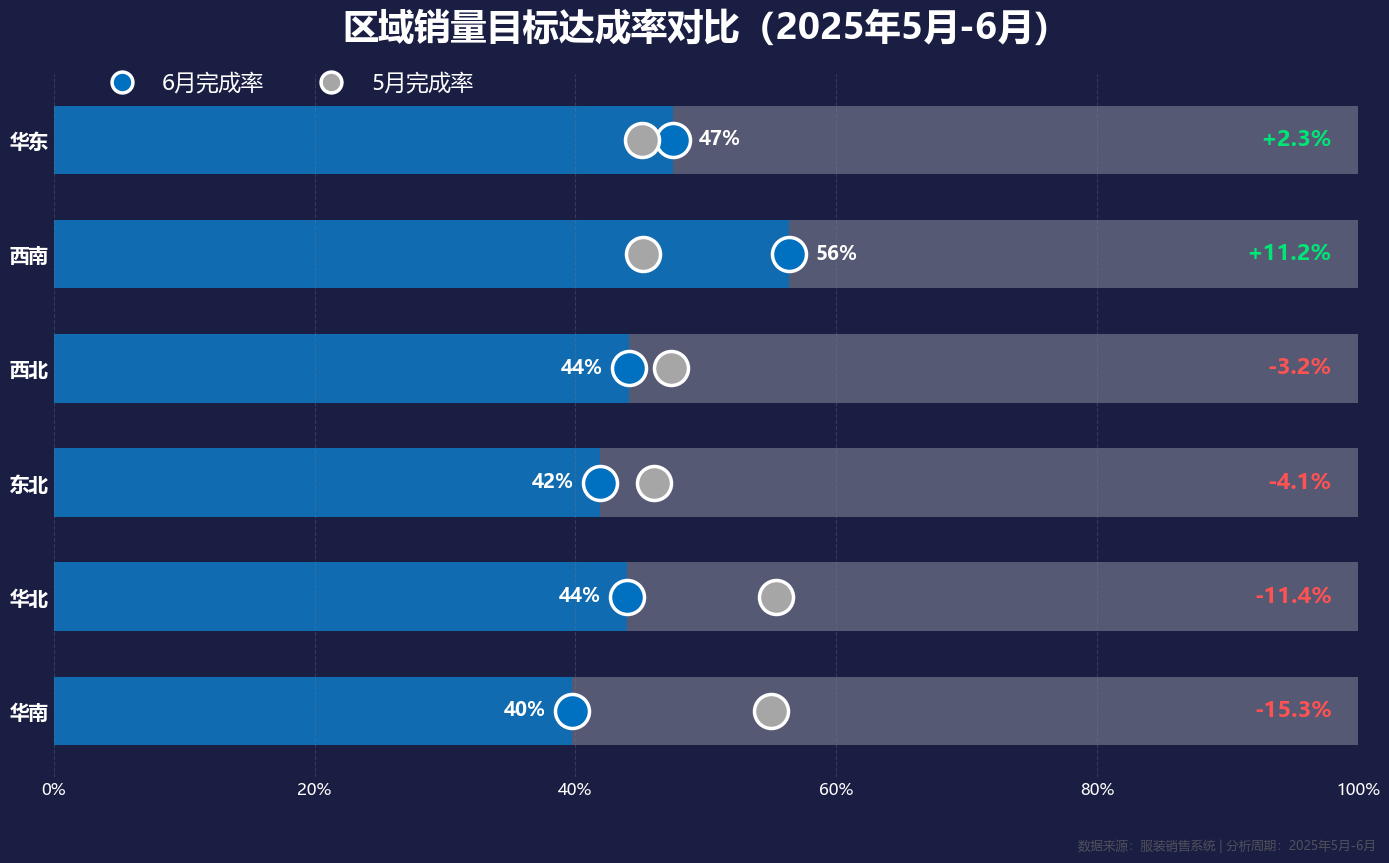

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
from matplotlib.lines import Line2D

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']
plt.rcParams['axes.unicode_minus'] = False

# 定义区域映射关系
REGION_MAPPING = {
    '华北': ['北京市', '天津市', '河北省', '山西省', '内蒙古自治区'],
    '华东': ['上海市', '江苏省', '浙江省', '安徽省', '福建省', '江西省', '山东省'],
    '华南': ['广东省', '广西壮族自治区', '海南省'],
    '西南': ['重庆市', '四川省', '贵州省', '云南省', '西藏自治区'],
    '西北': ['陕西省', '甘肃省', '青海省', '宁夏回族自治区', '新疆维吾尔自治区'],
    '东北': ['辽宁省', '吉林省', '黑龙江省']
}

try:
    # 读取订单数据
    df = pd.read_csv("../../数据生成/erp_order.csv", encoding='utf-8-sig', parse_dates=["下单时间"])
    
    # 验证必要字段
    required_columns = ['下单时间', '状态', '省份']
    missing_cols = [col for col in required_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"数据缺失必要字段: {', '.join(missing_cols)}")
    if df.empty:
        raise ValueError("订单数据为空")
    if df['状态'].isnull().all():
        raise ValueError("订单状态数据全部为空")
    
    # 创建省份到区域的映射字典
    province_to_region = {}
    for region, provinces in REGION_MAPPING.items():
        for province in provinces:
            province_to_region[province] = region
    
    # 添加区域列（处理可能的省份别名）
    df['区域'] = df['省份'].map(province_to_region)
    
    # 只保留成功映射的区域数据
    df = df.dropna(subset=['区域'])
    
    # 验证区域数据
    target_regions = ['华南', '华北', '东北', '西北', '西南', '华东']
    df = df[df['区域'].isin(target_regions)]
    
    # 数据预处理 - 筛选2025年5-6月数据
    df["年份"] = df["下单时间"].dt.year
    df["月份"] = df["下单时间"].dt.month
    
    # 仅保留2025年5月和6月的数据
    df = df[(df["年份"] == 2025) & (df["月份"].isin([5, 6]))]
    
    if df.empty:
        raise ValueError("筛选后无有效数据，请检查日期范围和区域过滤条件")
    
    # 区域月份完成率统计
    region_month_summary = (
        df.groupby(["区域", "月份"])["状态"]
        .value_counts()
        .unstack(fill_value=0)
        .reset_index()
    )
    
    status_columns = ["待付款", "已付款", "已发货", "已完成", "已取消"]
    for s in status_columns:
        if s not in region_month_summary.columns:
            region_month_summary[s] = 0
    
    region_month_summary["总订单数"] = region_month_summary[status_columns].sum(axis=1)
    region_month_summary["完成率"] = region_month_summary["已完成"] / region_month_summary["总订单数"]
    
    # 重塑数据为区域×月份格式
    pivot_data = region_month_summary.pivot(
        index="区域", 
        columns="月份", 
        values="完成率"
    ).reset_index()
    
    # 确保区域顺序（按目标区域顺序）
    pivot_data = pivot_data.set_index("区域").reindex(target_regions).reset_index()
    
    # 填充可能缺失的月份数据
    if 5 not in pivot_data.columns:
        pivot_data[5] = 0
    if 6 not in pivot_data.columns:
        pivot_data[6] = 0
    
    # 转换为百分比
    rates_may = pivot_data[5] * 100
    rates_june = pivot_data[6] * 100
    
    # 创建绘图
    fig, ax = plt.subplots(figsize=(14, 9), dpi=100)
    fig.patch.set_facecolor('#1A1E43')
    ax.set_facecolor('#1A1E43')
    
    # 隐藏边框
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # 设置区域位置
    y_labels = pivot_data["区域"]
    y_pos = np.arange(len(y_labels))
    
    # 绘制灰色底条
    ax.barh(y_pos, [100] * len(y_labels), color='#717389', height=0.6, alpha=0.7)
    
    # 绘制6月数据条状
    ax.barh(y_pos, rates_june, height=0.6, color='#0070c0', alpha=0.8, label='6月完成率')

    # 绘制6月数据
    ax.scatter(rates_june, y_pos, s=600, color='#0070c0', edgecolors='white', 
                linewidths=2.5, zorder=5, label='6月完成率')
    
    # 绘制5月数据
    ax.scatter(rates_may, y_pos, s=600, color='#a6a6a6', edgecolors='white', 
                linewidths=2.5, zorder=5, label='5月完成率')
    
    # 添加百分比标注
    for i, (rate_may, rate_june) in enumerate(zip(rates_may, rates_june)):
        if rate_june > rate_may:
            # 6月完成率标注，在右侧
            if rate_june > 92:
                ax.text(rate_june - 3, y_pos[i], f"{rate_june:.0f}%", 
                        va='center', ha='right', color='white', fontsize=14, fontweight='bold')
            else:
                ax.text(rate_june + 2, y_pos[i], f"{rate_june:.0f}%", 
                        va='center', ha='left', color='white', fontsize=14, fontweight='bold')
        else:
            # 6月完成率标注，在左侧
            ax.text(rate_june - 2, y_pos[i], f"{rate_june:.0f}%", 
                    va='center', ha='right', color='white', fontsize=14, fontweight='bold')
    
    # 计算并标注变化值
    changes = rates_june - rates_may
    for i, change in enumerate(changes):
        change_color = '#00E676' if change > 0 else '#FF5252'
        sign = '+' if change > 0 else ''
        # 在右侧固定位置显示变化值
        ax.text(98, y_pos[i], f"{sign}{change:.1f}%", 
                va='center', ha='right', color=change_color, fontsize=16, fontweight='bold')
    
    # 设置Y轴标签
    ax.set_yticks(y_pos)
    ax.set_yticklabels(y_labels, color='white', fontsize=14, fontweight='bold')
    
    # 设置X轴样式
    ax.set_xlim(0, 100)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis='x', colors='white', labelsize=12)
    ax.tick_params(axis='y', length=0)
    ax.grid(axis='x', linestyle='--', alpha=0.2, color='#3A4260')
    ax.grid(axis='y', visible=False)
    ax.tick_params(axis='x', length=0)
    ax.tick_params(axis='y', length=0)
    
    # 添加标题
    plt.title("区域销量目标达成率对比（2025年5月-6月）", fontsize=26, fontweight="bold", color="white", pad=25)
    
    # 创建自定义图例
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', 
                label='6月完成率', markerfacecolor='#0070c0', 
                markersize=15, markeredgewidth=2.5, linestyle='None'),
        Line2D([0], [0], marker='o', color='w', 
                label='5月完成率', markerfacecolor='#a6a6a6', 
                markersize=15, markeredgewidth=2.5, linestyle='None')
    ]
    legend = ax.legend(
        handles=legend_elements, 
        loc='upper left',
        frameon=False,
        labelcolor='white',
        fontsize=16,
        bbox_to_anchor=(0.02, 1.03),
        ncol=2
    )

    # 图例不显示框或横线
    legend.get_frame().set_linewidth(0)

    # 添加数据来源
    plt.figtext(
        0.88, 0,
        '数据来源：服装销售系统 | 分析周期：2025年5月-6月',
        ha='center', fontsize=9, color='#666666', alpha=0.7
    )
    
    # 添加网格线
    ax.grid(axis='x', linestyle='--', alpha=0.3, color='#777b92')
    ax.grid(axis='y', visible=False)
    
    plt.tight_layout(rect=(0, 0.04, 1, 0.95))
    
    # 保存高清图片
    plt.savefig("区域销量目标达成率对比（2025年5月-6月）.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

except Exception as e:
    print(f"图表生成失败: {str(e)}")
    raise

# 分析

- **华东区域**：
  - 5月完成率：47%
  - 6月完成率：49.3%（增长2.3%）
  - 分析：华东区域在6月的销量目标达成率有所提升，显示出积极的市场响应和销售策略的有效性。

- **西南区域**：
  - 5月完成率：56%
  - 6月完成率：44%（下降12%）
  - 分析：西南区域在6月的销量目标达成率显著下降，可能需要重新评估市场策略或应对市场变化。

- **西北区域**：
  - 5月完成率：44%
  - 6月完成率：40.8%（下降3.2%）
  - 分析：西北区域的达成率略有下降，可能需要关注市场动态和销售执行的调整。

- **东北区域**：
  - 5月完成率：42%
  - 6月完成率：37.9%（下降4.1%）
  - 分析：东北区域的达成率下降，可能反映了市场需求的减弱或竞争的加剧。

- **华北区域**：
  - 5月完成率：44%
  - 6月完成率：38.6%（下降11.4%）
  - 分析：华北区域的达成率下降幅度较大，可能需要深入分析原因并采取相应措施。

- **华南区域**：
  - 5月完成率：40%
  - 6月完成率：24.7%（下降15.3%）
  - 分析：华南区域的达成率下降最为显著，可能需要紧急调整销售策略和市场定位。


# 结论

从区域销量目标达成率对比分析来看，华东区域表现最佳，达成率有所提升。而西南、西北、东北、华北和华南区域的达成率均有所下降，尤其是华南区域，下降幅度最大。这可能指示了市场需求的变化、销售策略的不足或竞争环境的挑战。